<>:94: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\p'
C:\Users\911\AppData\Local\Temp\ipykernel_26248\2624009500.py:94: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('误差 $e_n = |\pi - \pi_n|$', fontsize=10)
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting wit

📊 收敛率验证结果：
h1 = 0.007812, e1 = 3.1540265702e-04
h2 = 0.003906, e2 = 7.8852445492e-05
计算得到的收敛率 ≈ 2.0000
理论二阶收敛率 = 2.0000


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


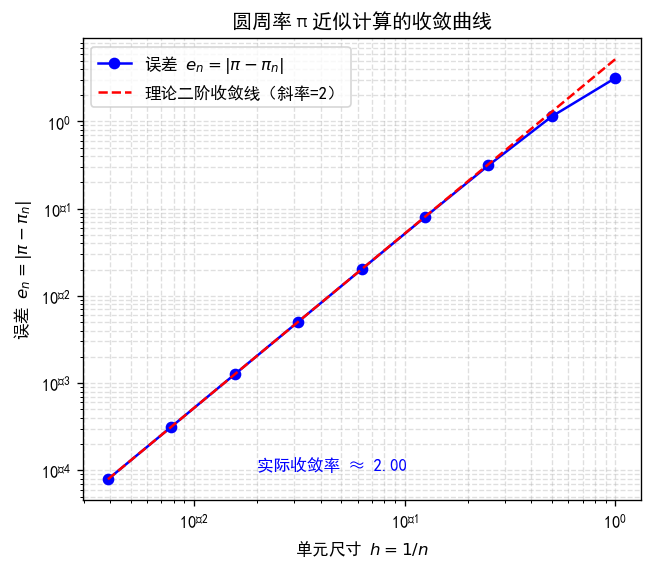

In [7]:
# ----------------------
# 1. 导入需要的库
# ----------------------
import math       # 用于数学计算（圆周率、正弦函数）
import numpy as np # 用于数值计算（收敛率计算、数组操作）
import matplotlib.pyplot as plt # 用于画图

# ----------------------
# 关键配置：解决Matplotlib中文乱码问题
# ----------------------
# 设置默认字体为黑体，确保中文正常显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
# 解决坐标轴负号显示为方框的问题
plt.rcParams['axes.unicode_minus'] = False

# ----------------------
# 2. 生成和课件完全一致的数据
# ----------------------
# 课件里的多边形边数n（从1到256，每次翻倍）
n_list = [1, 2, 4, 8, 16, 32, 64, 128, 256]
# π的精确值（math.pi是Python内置的高精度圆周率）
pi_exact = math.pi

# 初始化两个空列表，用来存单元尺寸h和误差e_n
h_list = []      # h = 1/n，单元尺寸
error_list = []  # e_n = |π - π_n|，近似值和真实值的误差

# 循环计算每个n对应的近似π值、误差和单元尺寸
for n in n_list:
    # 用正n边形周长近似圆周长，推导得到的π近似值公式：π_n = n * sin(π/n)
    pi_n = n * math.sin(math.pi / n)
    # 计算误差：近似值和真实π的差的绝对值
    error = abs(pi_exact - pi_n)
    # 单元尺寸h = 1/n，网格越细h越小
    h = 1 / n
    # 把计算好的h和误差存到列表里
    h_list.append(h)
    error_list.append(error)

# ----------------------
# 3. 计算收敛率（验证是不是接近2）
# ----------------------
# 收敛率计算公式：order = log(e1/e2) / log(h1/h2)
# 取最后两组细网格数据（高阶项影响小，更接近理论二阶）
h1, e1 = h_list[-2], error_list[-2]  # n=128对应的h和误差
h2, e2 = h_list[-1], error_list[-1]  # n=256对应的h和误差

# 计算收敛率，log以10为底
order = np.log(e1 / e2) / np.log(h1 / h2)

# 打印结果，方便你在作业里写结论
print("="*50)
print("📊 收敛率验证结果：")
print(f"h1 = {h1:.6f}, e1 = {e1:.10e}")
print(f"h2 = {h2:.6f}, e2 = {e2:.10e}")
print(f"计算得到的收敛率 ≈ {order:.4f}")
print("理论二阶收敛率 = 2.0000")
print("="*50)

# ----------------------
# 4. 画 log-log 收敛曲线（和课件右上角的图一致）
# ----------------------
# 创建画布，设置尺寸和分辨率
plt.figure(figsize=(6, 5), dpi=120)

# 画误差曲线：log-log坐标，蓝色圆点+实线
plt.loglog(
    h_list, error_list,          # x轴是h，y轴是误差
    marker='o',                  # 用圆点标记每个数据点
    linestyle='-',               # 用实线连接点
    color='blue',                # 曲线颜色设为蓝色
    label=r'误差 $e_n = |\pi - \pi_n|$' # 图例文字（带公式）
)

# 画理论二阶收敛参考线（斜率=2）
# 取h的范围从1/256到1，误差按e ~ (π³/6)h²计算
ref_h = np.array([1/256, 1])
ref_err = (math.pi**3 / 6) * (ref_h ** 2) # 对应泰勒展开的主导项
plt.loglog(
    ref_h, ref_err, 
    'r--',                        # 红色虚线
    label=f'理论二阶收敛线（斜率=2）' # 图例文字
)

# 在图上标注实际计算得到的收敛率
plt.text(
    0.02, 1e-4,                   # 标注的位置（x,y）
    f'实际收敛率 ≈ {order:.2f}',  # 显示的文字
    color='blue', fontsize=10    # 文字颜色和大小
)

# 设置坐标轴标签和标题（中文）
plt.xlabel('单元尺寸 $h = 1/n$', fontsize=10)
plt.ylabel('误差 $e_n = |\pi - \pi_n|$', fontsize=10)
plt.title('圆周率π近似计算的收敛曲线', fontsize=12)

# 显示网格线（主网格+次网格）
plt.grid(True, which="both", ls="--", alpha=0.4)
# 显示图例（说明每条线的含义）
plt.legend()

# 显示图片
plt.show()

# ----------------------
# 5. 生成 Tecplot 可导入的 .dat 文件（可选，如果你之后要用Tecplot画图）
# ----------------------
# 以写入模式打开文件，编码设为utf-8避免乱码
with open("pi_convergence.dat", "w", encoding="utf-8") as f:
    # Tecplot文件的标题
    f.write('TITLE = "Pi Convergence Test"\n')
    # 定义变量：h和Error
    f.write('VARIABLES = "h", "Error"\n')
    # 定义数据区：点格式，数据点个数是len(h_list)
    f.write('ZONE T="Convergence Curve", I={}, J=1, K=1, F=POINT\n'.format(len(h_list)))
    # 逐行写入数据，科学计数法保留15位小数
    for h, err in zip(h_list, error_list):
        f.write(f"{h:.15e} {err:.15e}\n")